# Customer Churn Clustering Analysis

This notebook performs clustering on the processed churn dataset. The target variable `churn` is excluded from the clustering inputs to avoid leakage. Cluster labels are then analysed against churn afterwards.

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import joblib

sns.set_theme(style="whitegrid")


In [ ]:
# Load processed dataset
df = pd.read_csv("../data preparation/data/processed/churn_processed.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
df.head()


FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/churn_processed.csv'

## 1. Prepare clustering features

The processed dataset is already numeric, so additional one-hot encoding is not needed. The target column `churn` is removed before clustering.

In [ ]:
# Separate clustering features from target
X = df.drop(columns=["churn"]).copy()

print("Feature matrix shape:", X.shape)
X.head()


Feature matrix shape: (7043, 10)


,seniorcitizen,tenure,monthlycharges,gender_male,dependents_yes,phoneservice_yes,multiplelines_yes,internetservice_fiber optic,contract_one year,contract_two year
0,0,1,25,0,0,0,0,0,0,0
1,0,41,25,1,0,1,0,0,1,0
2,0,52,19,0,1,1,0,0,0,0
3,0,1,76,0,0,1,0,0,1,0
4,0,67,51,1,0,1,0,1,0,0


## 2. Scale features

K-Means is distance-based, so scaling is important. Here all input features are standardised so that higher-range variables do not dominate the clustering solution.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 3. Choose the number of clusters

The elbow method is used first, and silhouette score is added as a second check. Relying only on elbow can be too subjective.

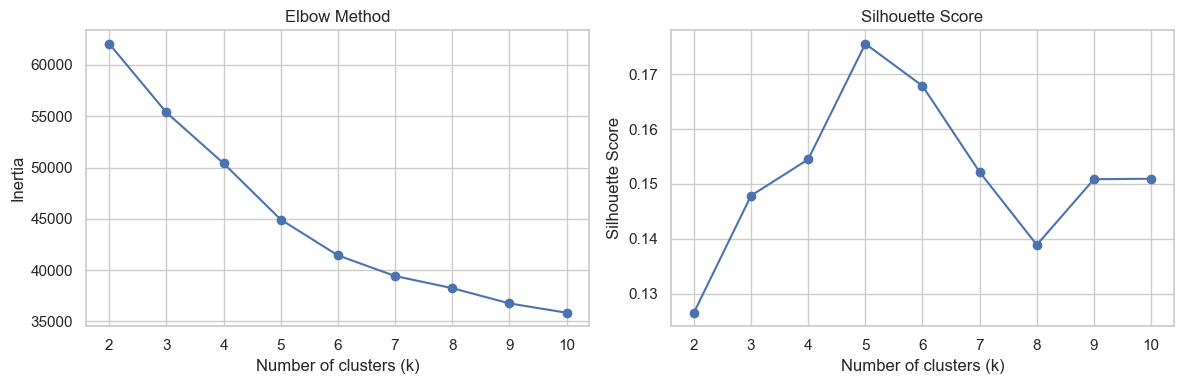

In [ ]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(list(K_range), inertia, marker="o")
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("Number of clusters (k)")
ax[0].set_ylabel("Inertia")

ax[1].plot(list(K_range), silhouette_scores, marker="o")
ax[1].set_title("Silhouette Score")
ax[1].set_xlabel("Number of clusters (k)")
ax[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()


## 4. Fit final K-Means model


In [ ]:
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Save model and cluster labels
df_clustered = df.copy()
df_clustered["cluster"] = cluster_labels

joblib.dump(kmeans, "kmeans_model.pkl")
df_clustered.head()


,seniorcitizen,tenure,monthlycharges,gender_male,dependents_yes,phoneservice_yes,multiplelines_yes,internetservice_fiber optic,contract_one year,contract_two year,churn,cluster
0,0,1,25,0,0,0,0,0,0,0,1,2
1,0,41,25,1,0,1,0,0,1,0,0,1
2,0,52,19,0,1,1,0,0,0,0,0,1
3,0,1,76,0,0,1,0,0,1,0,1,1
4,0,67,51,1,0,1,0,1,0,0,0,1


## 5. PCA visualisation

PCA is used only for visualisation. It is not part of the clustering model itself.

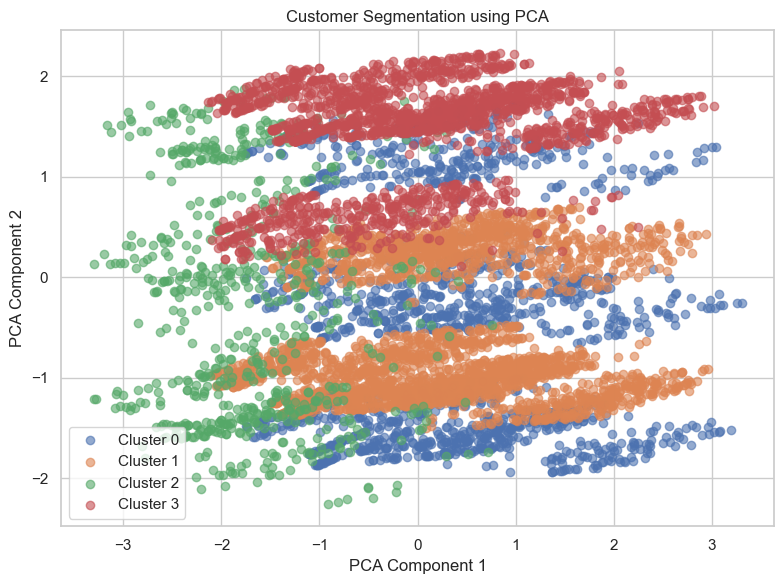

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_clustered["pca1"] = X_pca[:, 0]
df_clustered["pca2"] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
for cluster in sorted(df_clustered["cluster"].unique()):
    subset = df_clustered[df_clustered["cluster"] == cluster]
    plt.scatter(subset["pca1"], subset["pca2"], label=f"Cluster {cluster}", alpha=0.6)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Segmentation using PCA")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Cluster summary

Summarise the original features by cluster to interpret the segments.

In [ ]:
cluster_summary = df_clustered.groupby("cluster")[["tenure", "monthlycharges"]].mean()
cluster_summary


,tenure,monthlycharges
cluster,,
0,32.519268,67.947093
1,31.293297,67.925145
2,31.737537,42.017595
3,34.154944,65.457959


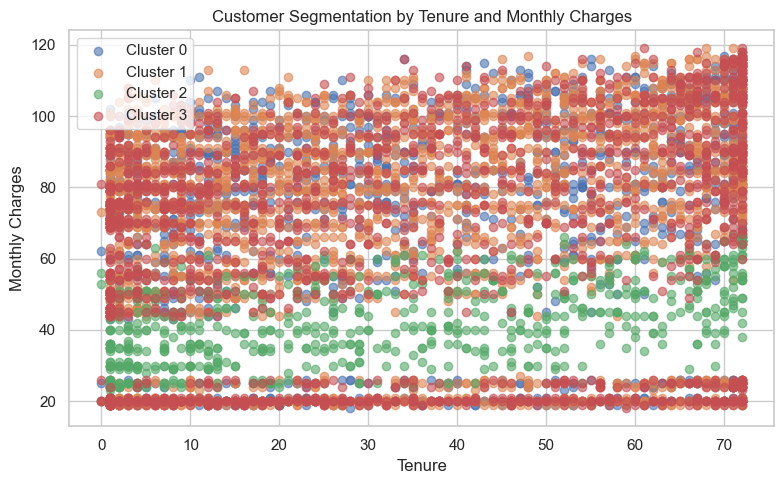

In [ ]:
plt.figure(figsize=(8, 5))
for cluster in sorted(df_clustered["cluster"].unique()):
    subset = df_clustered[df_clustered["cluster"] == cluster]
    plt.scatter(
        subset["tenure"],
        subset["monthlycharges"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")
plt.title("Customer Segmentation by Tenure and Monthly Charges")
plt.legend()
plt.tight_layout()
plt.show()


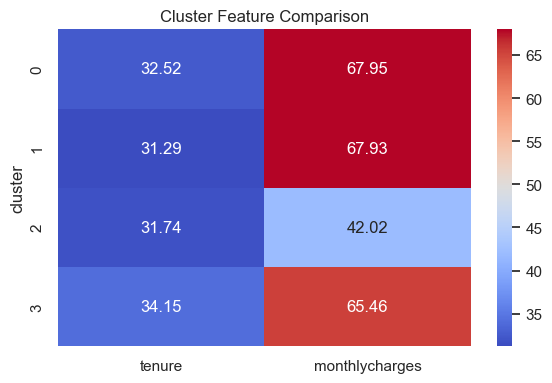

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(cluster_summary, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Cluster Feature Comparison")
plt.tight_layout()
plt.show()


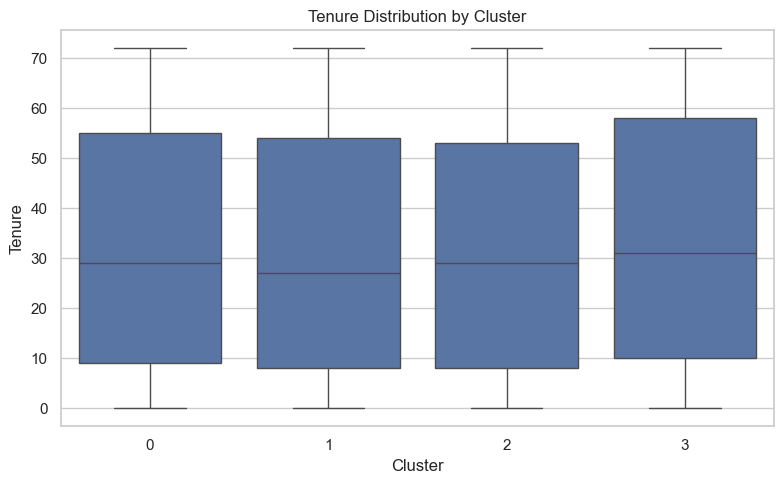

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="cluster", y="tenure", data=df_clustered)
plt.xlabel("Cluster")
plt.ylabel("Tenure")
plt.title("Tenure Distribution by Cluster")
plt.tight_layout()
plt.show()


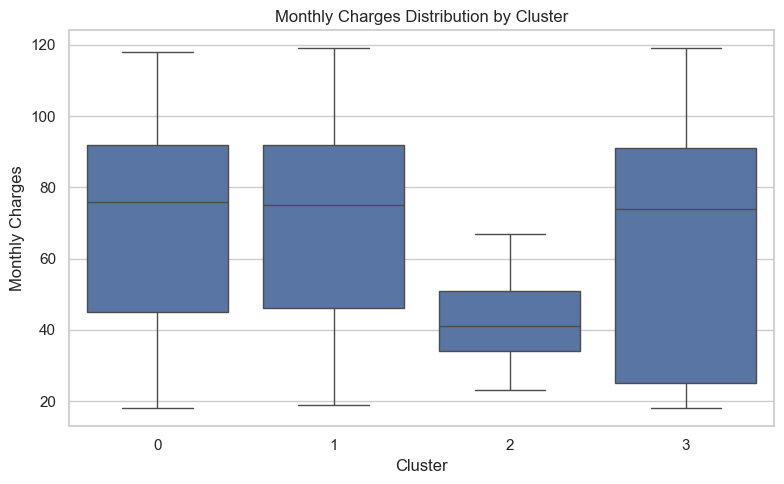

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="cluster", y="monthlycharges", data=df_clustered)
plt.xlabel("Cluster")
plt.ylabel("Monthly Charges")
plt.title("Monthly Charges Distribution by Cluster")
plt.tight_layout()
plt.show()


## 7. Compare churn across clusters

Churn is used here only for interpretation after clustering, not as an input to create the clusters.

In [ ]:
churn_analysis = pd.crosstab(df_clustered["cluster"], df_clustered["churn"], normalize="index") * 100
churn_analysis


churn,0,1
cluster,,
0,74.199869,25.800131
1,71.146649,28.853351
2,75.073314,24.926686
3,75.885775,24.114225


In [ ]:
churn_rate = df_clustered.groupby("cluster")["churn"].mean().sort_values(ascending=False)
churn_rate


cluster
1    0.288534
0    0.258001
2    0.249267
3    0.241142
Name: churn, dtype: float64

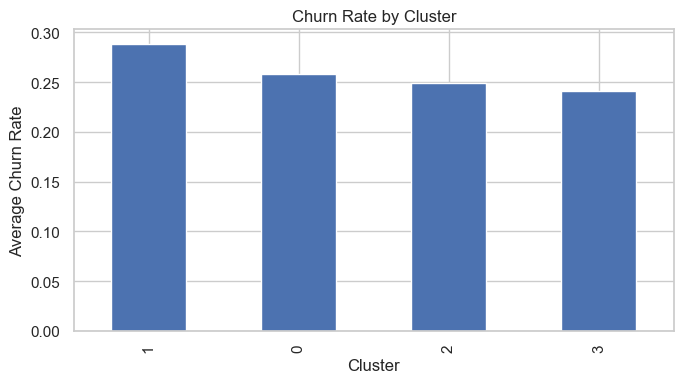

In [ ]:
plt.figure(figsize=(7, 4))
churn_rate.plot(kind="bar")
plt.xlabel("Cluster")
plt.ylabel("Average Churn Rate")
plt.title("Churn Rate by Cluster")
plt.tight_layout()
plt.show()


## Cluster Profiling and Interpretation

The PCA visualization helps show how customers are grouped, but it does not directly explain what type of customer is in each cluster. The following cells profile each cluster using churn rate, tenure, monthly charges, and reconstructed categorical features such as contract type and internet type.


In [ ]:
# Cluster size
df_clustered['cluster'].value_counts().sort_index()


cluster
0    1531
1    2939
2     682
3    1891
Name: count, dtype: int64

In [ ]:
# Numeric profile of each cluster
cluster_profile = df_clustered.groupby('cluster').agg({
    'tenure': 'mean',
    'monthlycharges': 'mean',
    'seniorcitizen': 'mean',
    'churn': 'mean'
}).round(2)

cluster_profile['size'] = df_clustered['cluster'].value_counts().sort_index()
cluster_profile


,tenure,monthlycharges,seniorcitizen,churn,size
cluster,,,,,
0,32.52,67.95,0.15,0.26,1531
1,31.29,67.93,0.18,0.29,2939
2,31.74,42.02,0.15,0.25,682
3,34.15,65.46,0.14,0.24,1891


In [ ]:
# Reconstruct readable contract type from one-hot encoded columns
def contract_type(row):
    if row['contract_one year'] == 1:
        return 'One year'
    elif row['contract_two year'] == 1:
        return 'Two year'
    else:
        return 'Month-to-month'

df_clustered['contract_type'] = df_clustered.apply(contract_type, axis=1)
df_clustered[['cluster', 'contract_type']].head()


,cluster,contract_type
0,2,Month-to-month
1,1,One year
2,1,Month-to-month
3,1,One year
4,1,Month-to-month


In [ ]:
# Contract mix by cluster (percent within each cluster)
pd.crosstab(df_clustered['cluster'], df_clustered['contract_type'], normalize='index').mul(100).round(2)


contract_type,Month-to-month,One year,Two year
cluster,,,
0,0.00,0.00,100.00
1,70.64,29.36,0.00
2,52.93,23.02,24.05
3,76.04,23.96,0.00


In [ ]:
# Reconstruct readable internet type from one-hot encoded columns
def internet_type(row):
    if row['internetservice_fiber optic'] == 1:
        return 'Fiber optic'
    else:
        return 'DSL'

df_clustered['internet_type'] = df_clustered.apply(internet_type, axis=1)
df_clustered[['cluster', 'internet_type']].head()


,cluster,internet_type
0,2,DSL
1,1,DSL
2,1,DSL
3,1,DSL
4,1,Fiber optic


In [ ]:
# Internet service mix by cluster (percent within each cluster)
pd.crosstab(df_clustered['cluster'], df_clustered['internet_type'], normalize='index').mul(100).round(2)


internet_type,DSL,Fiber optic
cluster,,
0,74.98,25.02
1,77.75,22.25
2,55.87,44.13
3,7.03,92.97


In [ ]:
# Gender mix by cluster (0 = female, 1 = male)
pd.crosstab(df_clustered['cluster'], df_clustered['gender_male'], normalize='index').mul(100).round(2)


gender_male,0,1
cluster,,
0,48.60,51.40
1,50.77,49.23
2,48.53,51.47
3,48.70,51.30


In [ ]:
# Dependents mix by cluster (0 = no, 1 = yes)
pd.crosstab(df_clustered['cluster'], df_clustered['dependents_yes'], normalize='index').mul(100).round(2)


dependents_yes,0,1
cluster,,
0,70.35,29.65
1,80.98,19.02
2,69.79,30.21
3,52.88,47.12


## How to Interpret the Clusters

Use the outputs above in this order:

1. **Cluster size** shows how many customers are in each group.
2. **Cluster profile** shows the average tenure, monthly charges, senior citizen proportion, and churn rate for each group.
3. **Contract mix** shows whether the cluster is mostly month-to-month, one-year, or two-year customers.
4. **Internet type mix** shows whether the cluster is mostly DSL or Fiber optic customers.
5. **Gender and dependents mix** help describe the customer profile further.

The cluster with the highest average `churn` is the customer segment most associated with churn risk. The features of that cluster describe what type of customer is in that group.
